# 06 — Cross-Dataset Benchmark: OOD Probe Evaluation

**Goal:** Evaluate TriviaQA-trained probes on out-of-distribution datasets to measure generalization.

- Probes are **frozen** (trained in notebook 05 on TriviaQA) — no retraining here.
- We run the full semantic energy pipeline on a new dataset and compare:
  - **Teachers** (full 5-sample generation + clustering) as upper bound
  - **SLT / TBG probes** (single forward pass) as efficient alternatives
- All metrics are computed against **ground-truth correctness**, not teacher labels.

Run this notebook **three times** with different `EVAL_DATASET` settings:
1. `trivia_qa` (held-out, offset=1000) — in-distribution baseline
2. `nq_open` — Natural Questions Open
3. `squad` — Stanford Question Answering Dataset

## 0 — Configuration

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION — Change EVAL_DATASET to switch benchmark target
# ══════════════════════════════════════════════════════════════════════════════

MODEL_ID            = "Qwen/Qwen3-8B"
USE_8BIT            = True

# ── Evaluation dataset (change this per run) ─────────────────────────────────
EVAL_DATASET        = "squad"      # "trivia_qa", "nq_open", or "squad"
EVAL_DATASET_CONFIG = ""            # "rc" for trivia_qa, None for others
EVAL_SPLIT          = "validation"
DATASET_OFFSET      = 0              # For trivia_qa: set to 1000 to skip training data

# ── Training dataset (probes were trained on this) ───────────────────────────
TRAIN_DATASET       = "trivia_qa"

# ── Generation settings ──────────────────────────────────────────────────────
NUM_QUESTIONS       = 200
NUM_SAMPLES         = 5
CHECKPOINT_EVERY    = 50

# ── Derived names (auto-generated) ───────────────────────────────────────────
import re
MODEL_SHORT  = re.sub(r'[^a-z0-9]', '-', MODEL_ID.split('/')[-1].lower()).strip('-')
EVAL_SHORT   = EVAL_DATASET.replace('_', '')
TRAIN_SHORT  = TRAIN_DATASET.replace('_', '')
MODEL_LABEL  = MODEL_ID.split('/')[-1]

# Probe bundle comes from training dataset
PROBE_FILENAME = f"probes_{MODEL_SHORT}_{TRAIN_SHORT}.pkl"

print(f"Model:          {MODEL_ID}")
print(f"Eval dataset:   {EVAL_DATASET} (offset={DATASET_OFFSET})")
print(f"Train dataset:  {TRAIN_DATASET} (probes from)")
print(f"Questions:      {NUM_QUESTIONS} x {NUM_SAMPLES} samples")
print(f"Probe bundle:   {PROBE_FILENAME}")

Model:          Qwen/Qwen3-8B
Eval dataset:   squad (offset=0)
Train dataset:  trivia_qa (probes from)
Questions:      200 x 5 samples
Probe bundle:   probes_qwen3-8b_triviaqa.pkl


In [2]:
import sys, os, re, math, pickle, glob, time, warnings, hashlib
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')

REPO_ROOT    = os.path.abspath(os.path.join(os.getcwd(), '..'))
BACKEND_PATH = os.path.join(REPO_ROOT, 'backend')
DATA_DIR     = os.path.join(REPO_ROOT, 'backend', 'data')
MODELS_DIR   = os.path.join(REPO_ROOT, 'backend', 'models')
FIGS_DIR     = os.path.join(REPO_ROOT, 'notebooks', 'figures')
for d in [DATA_DIR, MODELS_DIR, FIGS_DIR]:
    os.makedirs(d, exist_ok=True)
if BACKEND_PATH not in sys.path:
    sys.path.insert(0, BACKEND_PATH)

np.random.seed(42)
print(f"Repo root : {REPO_ROOT}")
print(f"Data dir  : {DATA_DIR}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

Repo root : d:\Github Repositories\SemanticEnergy
Data dir  : d:\Github Repositories\SemanticEnergy\backend\data
CUDA: True
GPU: NVIDIA GeForce RTX 3060
VRAM: 12.0 GB


In [3]:
# ── Load pre-trained probe bundle ────────────────────────────────────────────
PROBE_PATH = os.path.join(MODELS_DIR, PROBE_FILENAME)
assert os.path.exists(PROBE_PATH), f"Probe bundle not found: {PROBE_PATH}\nRun notebook 05 first."

with open(PROBE_PATH, 'rb') as f:
    probe_bundle = pickle.load(f)

# Reconstruct trained_probes dict (same format notebook 05 uses)
trained_probes = {}
for prefix in ['slt_energy', 'tbg_energy', 'slt_entropy', 'tbg_entropy']:
    tok = 'slt' if prefix.startswith('slt') else 'tbg'
    teacher = 'energy' if 'energy' in prefix else 'entropy'
    lr_key = f'best_{teacher}_{tok}_range'
    trained_probes[prefix] = {
        'probe':       probe_bundle[f'{prefix}_probe'],
        'scaler':      probe_bundle[f'{prefix}_scaler'],
        'layer_range': probe_bundle[lr_key],
        'token':       tok,
    }

T_energy  = probe_bundle['energy_threshold']
T_entropy = probe_bundle['entropy_threshold']

print(f"Probe bundle loaded: {PROBE_FILENAME}")
print(f"  Trained on:       {probe_bundle.get('model_id', 'N/A')} / {probe_bundle.get('dataset', 'N/A')}")
print(f"  T_energy={T_energy:.4f}, T_entropy={T_entropy:.4f}")
for p, info in trained_probes.items():
    print(f"  {p}: layers {info['layer_range']}, token={info['token']}")

Probe bundle loaded: probes_qwen3-8b_triviaqa.pkl
  Trained on:       Qwen/Qwen3-8B / trivia_qa
  T_energy=0.6682, T_entropy=0.5556
  slt_energy: layers (24, 28), token=slt
  tbg_energy: layers (7, 11), token=tbg
  slt_entropy: layers (24, 28), token=slt
  tbg_entropy: layers (7, 11), token=tbg


## 1 — Dataset Loading & Generation

In [4]:
# ── Dataset adapter: universal get_refs / get_uid / correctness ───────────────

def normalize_answer(text):
    text = text.lower()
    text = re.sub(r'\b(a|an|the)\b', ' ', text)
    text = re.sub(r'[^\w\s]', '', text)
    return ' '.join(text.split())

def is_correct(predicted_answer, reference_aliases):
    """Normalized substring match — works for TriviaQA, NQ-Open, SQuAD."""
    norm_pred = normalize_answer(predicted_answer)
    for ref in reference_aliases:
        if normalize_answer(ref) in norm_pred:
            return 1.0
    return 0.0

def get_refs(example):
    """Extract reference answers as a flat list of strings, any dataset format."""
    # TriviaQA: example['answer'] is a dict with 'aliases' key
    if 'answer' in example and isinstance(example['answer'], dict):
        return example['answer'].get('aliases', [example['answer'].get('value', '')])
    # NQ-Open: example['answer'] is a list of strings
    if 'answer' in example and isinstance(example['answer'], list):
        return example['answer']
    # SQuAD: example['answers'] (plural) has 'text' key (list of strings)
    if 'answers' in example:
        ans = example['answers']
        if isinstance(ans, dict) and 'text' in ans:
            return ans['text']
        if isinstance(ans, list):
            return [a['text'] if isinstance(a, dict) else str(a) for a in ans]
    return []

def get_uid(example):
    """Extract a unique ID from any dataset format."""
    for key in ['question_id', 'id', 'uid']:
        if key in example:
            return str(example[key])
    return hashlib.md5(example['question'].encode()).hexdigest()

correctness_fn = is_correct

# Quick sanity check
assert is_correct("The capital of France is Paris.", ["Paris"]) == 1.0
assert is_correct("Rolling Stones", ["The Beatles"]) == 0.0
print("Dataset adapter functions defined.")

Dataset adapter functions defined.


In [5]:
# ── Load evaluation dataset ──────────────────────────────────────────────────
from datasets import load_dataset

if EVAL_DATASET_CONFIG:
    raw_dataset = load_dataset(EVAL_DATASET, EVAL_DATASET_CONFIG, split=EVAL_SPLIT)
else:
    raw_dataset = load_dataset(EVAL_DATASET, split=EVAL_SPLIT)

end_idx = min(DATASET_OFFSET + NUM_QUESTIONS, len(raw_dataset))
dataset_subset = raw_dataset.select(range(DATASET_OFFSET, end_idx))
actual_n = len(dataset_subset)

print(f"Dataset:   {EVAL_DATASET} ({EVAL_SPLIT})")
print(f"Total:     {len(raw_dataset)} examples")
print(f"Selected:  [{DATASET_OFFSET}:{end_idx}] = {actual_n} examples")

# Validate adapter on first example
ex = dataset_subset[0]
refs = get_refs(ex)
uid  = get_uid(ex)
print(f"\nFirst example:")
print(f"  Q:    {ex['question'][:100]}")
print(f"  Refs: {refs[:5]}")
print(f"  UID:  {uid}")
assert len(refs) > 0, "get_refs() returned empty — check adapter logic for this dataset"

Dataset:   squad (validation)
Total:     10570 examples
Selected:  [0:200] = 200 examples

First example:
  Q:    Which NFL team represented the AFC at Super Bowl 50?
  Refs: ['Denver Broncos', 'Denver Broncos', 'Denver Broncos']
  UID:  56be4db0acb8001400a502ec


In [6]:
# ── Load model ───────────────────────────────────────────────────────────────
from engine import SemanticEngine, cal_flow, sum_normalize

print(f"Loading {MODEL_ID} (8bit={USE_8BIT})...")
engine = SemanticEngine(model_id=MODEL_ID, use_8bit=USE_8BIT)
NUM_LAYERS = engine.model.config.num_hidden_layers + 1
HIDDEN_DIM = engine.model.config.hidden_size
print(f"Model ready. {NUM_LAYERS} layers, {HIDDEN_DIM} hidden dim")
print(f"VRAM used: {torch.cuda.memory_allocated(0) / 1024**3:.1f} GB")

Loading Qwen/Qwen3-8B (8bit=True)...
[Engine] Loading model: Qwen/Qwen3-8B
[Engine] Using device: cuda:0 (NVIDIA GeForce RTX 3060)
[Engine] VRAM available: 12.0 GB
[Engine] Quantization enabled (8-bit: True)
[Engine] Tokenizer loaded.


Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

[Engine] Model loaded. VRAM used: 8.8 GB
Model ready. 37 layers, 4096 hidden dim
VRAM used: 8.8 GB


In [7]:
# ── Helper functions ─────────────────────────────────────────────────────────

def cluster_assignment_entropy(clusters):
    sizes = [len(c) for c in clusters]
    n = sum(sizes)
    probs = [s / n for s in sizes]
    return -sum(p * math.log(p + 1e-10) for p in probs)

def extract_hidden_states(engine, prompt_text, answer_text):
    tokenizer, model = engine.tokenizer, engine.model
    messages = [{'role': 'user', 'content': prompt_text}]
    prompt_only = SemanticEngine._safe_apply_chat_template(
        tokenizer, messages, tokenize=False, add_generation_prompt=True)
    prompt_ids = tokenizer(prompt_only, return_tensors='pt').input_ids
    prompt_len = prompt_ids.shape[1]
    full_text = prompt_only + answer_text
    full_inputs = tokenizer(full_text, return_tensors='pt').to('cuda:0')
    full_len = full_inputs.input_ids.shape[1]
    if full_len <= prompt_len + 1:
        return None, None
    with torch.no_grad():
        outputs = model(**full_inputs, output_hidden_states=True)
    hidden = torch.stack(outputs.hidden_states, dim=0)[:, 0, :, :].float().cpu()
    tbg_hidden = hidden[:, prompt_len - 1, :].numpy()
    slt_hidden = hidden[:, full_len - 2, :].numpy()
    del outputs, hidden
    torch.cuda.empty_cache()
    return tbg_hidden, slt_hidden

def extract_logit_feats(generated_data_0):
    logits = np.array(generated_data_0['logits'])
    n = len(logits)
    if n == 0:
        return {'mean_chosen_logit': 0., 'min_chosen_logit': 0., 'std_chosen_logit': 0., 'answer_len': 0}
    return {'mean_chosen_logit': float(np.mean(logits)), 'min_chosen_logit': float(np.min(logits)),
            'std_chosen_logit': float(np.std(logits)), 'answer_len': n}

print("Helper functions defined.")

Helper functions defined.


In [8]:
# ── Record generation ────────────────────────────────────────────────────────

def generate_record(engine, example, num_samples=5):
    question, uid, refs = example['question'], get_uid(example), get_refs(example)
    gen_data = engine.generate_responses(question, num_samples=num_samples)
    main_answer = gen_data[0]['answer']
    clusters = engine.find_semantic_clusters(question, [d['answer'] for d in gen_data])
    mci = next(idx for idx, c in enumerate(clusters) if 0 in c)
    probs_se, logits_se = cal_flow([d['probs'] for d in gen_data], [d['logits'] for d in gen_data], clusters, fermi_mu=None)
    ce = sum_normalize(logits_se)
    tbg, slt = extract_hidden_states(engine, question, main_answer)
    return {
        'uid': uid, 'question': question, 'main_answer': main_answer,
        'correctness': correctness_fn(main_answer, refs),
        'energy_score_raw': ce[mci], 'entropy_score_raw': cluster_assignment_entropy(clusters),
        'energy_label': None, 'entropy_label': None,
        'emb_last_tok_before_gen': tbg, 'emb_tok_before_eos': slt,
        'logit_feats': extract_logit_feats(gen_data[0]),
        'token_ids': gen_data[0]['token_ids'],
        'num_clusters': len(clusters), 'cluster_sizes': [len(c) for c in clusters],
    }

print("generate_record defined.")

generate_record defined.


In [9]:
# ── Generation loop with checkpointing ───────────────────────────────────────
CKPT_PREFIX = f'checkpoint_*_{MODEL_SHORT}_benchmark_{EVAL_SHORT}.pkl'

existing_ckpts = sorted(glob.glob(os.path.join(DATA_DIR, CKPT_PREFIX)),
                        key=lambda p: int(re.search(r'checkpoint_(\d+)', p).group(1)))
records, start_idx = [], 0
if existing_ckpts:
    with open(existing_ckpts[-1], 'rb') as f: records = pickle.load(f)
    start_idx = len(records)
    print(f"Resuming from {start_idx}")
else:
    print("Starting fresh.")

errors = []
for i in tqdm(range(start_idx, actual_n), desc='Generating'):
    try:
        records.append(generate_record(engine, dataset_subset[i], NUM_SAMPLES))
    except Exception as e:
        print(f"\nERROR {i}: {e}")
        errors.append({'index': i, 'error': str(e)})
        continue
    if (i + 1) % CHECKPOINT_EVERY == 0:
        p = os.path.join(DATA_DIR, f'checkpoint_{i+1}_{MODEL_SHORT}_benchmark_{EVAL_SHORT}.pkl')
        with open(p, 'wb') as f: pickle.dump(records, f)
        print(f"\nSaved {p}")
print(f"Done. {len(records)} records, {len(errors)} errors")

Starting fresh.


Generating:   0%|          | 0/200 [00:00<?, ?it/s]

Passing `generation_config` together with generation-related arguments=({'return_dict_in_generate', 'output_logits', 'output_scores'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


  [Sample 1/5] The Denver Broncos represented the AFC at Super Bowl 50....
  [Sample 2/5] The Denver Broncos represented the AFC at Super Bowl 50....
  [Sample 3/5] The Denver Broncos represented the AFC at Super Bowl 50....
  [Sample 4/5] The Denver Broncos represented the AFC at Super Bowl 50....
  [Sample 5/5] The Denver Broncos represented the AFC at Super Bowl 50....


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  [Sample 1/5] The Denver Broncos represented the NFC at Super Bowl 50....
  [Sample 2/5] Denver Broncos...
  [Sample 3/5] The Denver Broncos represented the NFC at Super Bowl 50....
  [Sample 4/5] The Denver Broncos represented the NFC at Super Bowl 50....
  [Sample 5/5] The Denver Broncos represented the NFC at Super Bowl 50....
  [Sample 1/5] Super Bowl 50 took place in Denver, Colorado....
  [Sample 2/5] Super Bowl 50 took place in Denver, Colorado....
  [Sample 3/5] Super Bowl 50 took place in Denver, Colorado at Sports Authority Field at Mile H...
  [Sample 4/5] Super Bowl 50 took place in Denver, Colorado....
  [Sample 5/5] Super Bowl 50 took place in Denver, Colorado....
  [Sample 1/5] The Denver Broncos....
  [Sample 2/5] The Denver Broncos....
  [Sample 3/5] The Denver Broncos....
  [Sample 4/5] The Denver Broncos....
  [Sample 5/5] The Denver Broncos....
  [Sample 1/5] Gold and silver were used to emphasize the 50th anniversary of the Super Bowl....
  [Sample 2/5] Gold and s

In [10]:
# ── Dataset summary ──────────────────────────────────────────────────────────
valid_records = [r for r in records if r['emb_tok_before_eos'] is not None
                 and r['emb_last_tok_before_gen'] is not None]
dropped = len(records) - len(valid_records)
if dropped > 0:
    print(f"Dropped {dropped} records with missing hidden states")

cs = np.array([r['correctness'] for r in valid_records])
es = np.array([r['energy_score_raw'] for r in valid_records])
hs = np.array([r['entropy_score_raw'] for r in valid_records])

print(f"\n{'='*60}")
print(f"Benchmark: {MODEL_LABEL} on {EVAL_DATASET}")
print(f"{'='*60}")
print(f"Valid records:    {len(valid_records)}")
print(f"Correctness rate: {cs.mean():.3f} ({cs.sum():.0f}/{len(cs)})")
print(f"Energy:  mean={es.mean():.4f}, std={es.std():.4f}")
print(f"Entropy: mean={hs.mean():.4f}, std={hs.std():.4f}")

if cs.mean() < 0.10 or cs.mean() > 0.95:
    print(f"\n*** WARNING: Extreme correctness rate ({cs.mean():.1%}) — "
          f"metrics may be unreliable with this class imbalance ***")

# Save final benchmark dataset
out_path = os.path.join(DATA_DIR, f'benchmark_{MODEL_SHORT}_{EVAL_SHORT}.pkl')
with open(out_path, 'wb') as f: pickle.dump(valid_records, f)
print(f"\nSaved: {out_path} ({os.path.getsize(out_path) / 1024**2:.1f} MB)")

Dropped 2 records with missing hidden states

Benchmark: Qwen3-8B on squad
Valid records:    198
Correctness rate: 0.273 (54/198)
Energy:  mean=0.6944, std=0.3082
Entropy: mean=0.5251, std=0.5045

Saved: d:\Github Repositories\SemanticEnergy\backend\data\benchmark_qwen3-8b_squad.pkl (229.0 MB)


## 2 — Evaluation with Pre-trained Probes

In [11]:
# ── Build ProbeDataset (no train/val/test split — all data is eval) ──────────

class ProbeDataset:
    def __init__(self, records, name='eval'):
        self.name, self.N = name, len(records)
        self.energy_score_raw  = np.array([r['energy_score_raw']  for r in records])
        self.entropy_score_raw = np.array([r['entropy_score_raw'] for r in records])
        self.correctness = np.array([r['correctness'] for r in records])
        self.tbg_states = np.stack([r['emb_last_tok_before_gen'] for r in records])
        self.slt_states = np.stack([r['emb_tok_before_eos']      for r in records])
        self.num_layers = self.tbg_states.shape[1]
        self.hidden_dim = self.tbg_states.shape[2]
        self.logit_feats = np.nan_to_num(np.array([
            [r['logit_feats']['mean_chosen_logit'], r['logit_feats']['min_chosen_logit'],
             r['logit_feats']['std_chosen_logit'], float(r['logit_feats']['answer_len'])]
            for r in records], dtype=np.float64), nan=0., posinf=0., neginf=0.)
        self.energy_label = None
        self.entropy_label = None
        print(f"ProbeDataset '{name}': N={self.N}, layers={self.num_layers}, hidden={self.hidden_dim}")

D_eval = ProbeDataset(valid_records, name=f'eval_{EVAL_SHORT}')

# Apply TriviaQA thresholds for binarization (zero-shot transfer)
D_eval.energy_label  = (D_eval.energy_score_raw  >= T_energy).astype(int)
D_eval.entropy_label = (D_eval.entropy_score_raw >= T_entropy).astype(int)

print(f"\nBinarization (TriviaQA thresholds — T_energy={T_energy:.4f}, T_entropy={T_entropy:.4f}):")
print(f"  Energy label balance:  {D_eval.energy_label.mean():.3f} positive")
print(f"  Entropy label balance: {D_eval.entropy_label.mean():.3f} positive")

ProbeDataset 'eval_squad': N=198, layers=37, hidden=4096

Binarization (TriviaQA thresholds — T_energy=0.6682, T_entropy=0.5556):
  Energy label balance:  0.551 positive
  Entropy label balance: 0.429 positive


In [12]:
# ── Evaluation functions ─────────────────────────────────────────────────────

def fpr_at_tpr(y_true, y_score, target_tpr=0.95):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    idx = np.where(tpr >= target_tpr)[0]
    if len(idx) == 0:
        return 1.0
    return float(fpr[idx[0]])

def full_eval(y_true, y_score):
    auroc = roc_auc_score(y_true, y_score)
    aupr  = average_precision_score(y_true, y_score)
    fpr95 = fpr_at_tpr(y_true, y_score, 0.95)
    return {'auroc': auroc, 'aupr': aupr, 'fpr95': fpr95}

def bootstrap_full_eval(y_true, y_score, n_boot=1000, ci=0.95):
    base = full_eval(y_true, y_score)
    boot = {'auroc': [], 'aupr': [], 'fpr95': []}
    rng = np.random.default_rng(0)
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), len(y_true))
        if len(np.unique(y_true[idx])) < 2: continue
        b = full_eval(y_true[idx], y_score[idx])
        for k in boot: boot[k].append(b[k])
    alpha = (1 - ci) / 2
    result = {}
    for k in base:
        result[k] = {
            'mean': base[k],
            'lo': np.percentile(boot[k], alpha * 100),
            'hi': np.percentile(boot[k], (1 - alpha) * 100),
        }
    return result

def get_range_X(D, lr, token='slt'):
    return (D.slt_states if token == 'slt' else D.tbg_states)[:, lr[0]:lr[1], :].reshape(D.N, -1)

def clean_X(X):
    return np.nan_to_num(np.array(X, dtype=np.float64), nan=0., posinf=0., neginf=0.)

def get_hall_score(pname, p_info, D):
    X = get_range_X(D, p_info['layer_range'], p_info['token'])
    s = p_info['probe'].predict_proba(p_info['scaler'].transform(clean_X(X)))[:, 1]
    return 1 - s if 'energy' in pname else s

def optimal_threshold(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    j = tpr - fpr
    return thresholds[np.argmax(j)]

def save_fig(name):
    p = os.path.join(FIGS_DIR, f'{name}_{MODEL_SHORT}.png')
    plt.savefig(p, dpi=120, bbox_inches='tight')
    print(f"Saved: {p}")

print("Evaluation functions defined.")

Evaluation functions defined.


In [13]:
# ── All-systems evaluation against ground-truth correctness ──────────────────
y_hall = 1 - D_eval.correctness

systems = [
    ('Energy teacher (UB)',  1 - D_eval.energy_score_raw),
    ('Entropy teacher (UB)', D_eval.entropy_score_raw),
    ('SLT energy probe',     get_hall_score('slt_energy', trained_probes['slt_energy'], D_eval)),
    ('TBG energy probe',     get_hall_score('tbg_energy', trained_probes['tbg_energy'], D_eval)),
    ('SLT entropy probe',    get_hall_score('slt_entropy', trained_probes['slt_entropy'], D_eval)),
    ('TBG entropy probe',    get_hall_score('tbg_entropy', trained_probes['tbg_entropy'], D_eval)),
]

print(f"\nHallucination Detection — {MODEL_LABEL} on {EVAL_DATASET} (n={D_eval.N})")
print(f"Hallucination rate: {y_hall.mean():.1%}\n")
print(f"{'System':<25} {'AUROC':>8} {'95% CI':>16} {'AUPR':>8} {'95% CI':>16} {'FPR@95':>8} {'95% CI':>16}")
print("-" * 100)

sys_results = []
for name, scores in systems:
    r = bootstrap_full_eval(y_hall, scores)
    sys_results.append((name, r))
    print(f"{name:<25} "
          f"{r['auroc']['mean']:>8.4f} [{r['auroc']['lo']:.4f}, {r['auroc']['hi']:.4f}]  "
          f"{r['aupr']['mean']:>8.4f} [{r['aupr']['lo']:.4f}, {r['aupr']['hi']:.4f}]  "
          f"{r['fpr95']['mean']:>8.4f} [{r['fpr95']['lo']:.4f}, {r['fpr95']['hi']:.4f}]")


Hallucination Detection — Qwen3-8B on squad (n=198)
Hallucination rate: 72.7%

System                       AUROC           95% CI     AUPR           95% CI   FPR@95           95% CI
----------------------------------------------------------------------------------------------------
Energy teacher (UB)         0.6687 [0.5799, 0.7476]    0.8284 [0.7672, 0.8831]    1.0000 [1.0000, 1.0000]
Entropy teacher (UB)        0.6598 [0.5700, 0.7395]    0.8056 [0.7398, 0.8688]    1.0000 [1.0000, 1.0000]
SLT energy probe            0.6938 [0.6035, 0.7751]    0.8287 [0.7533, 0.8989]    0.7407 [0.6429, 0.9039]
TBG energy probe            0.5442 [0.4569, 0.6293]    0.7769 [0.7032, 0.8504]    1.0000 [0.9591, 1.0000]
SLT entropy probe           0.6422 [0.5469, 0.7302]    0.7872 [0.7097, 0.8723]    0.8148 [0.6842, 0.9388]
TBG entropy probe           0.4653 [0.4331, 0.5050]    0.7133 [0.6501, 0.7718]    1.0000 [1.0000, 1.0000]


Saved: d:\Github Repositories\SemanticEnergy\notebooks\figures\performance_comparison_benchmark_squad_qwen3-8b.png


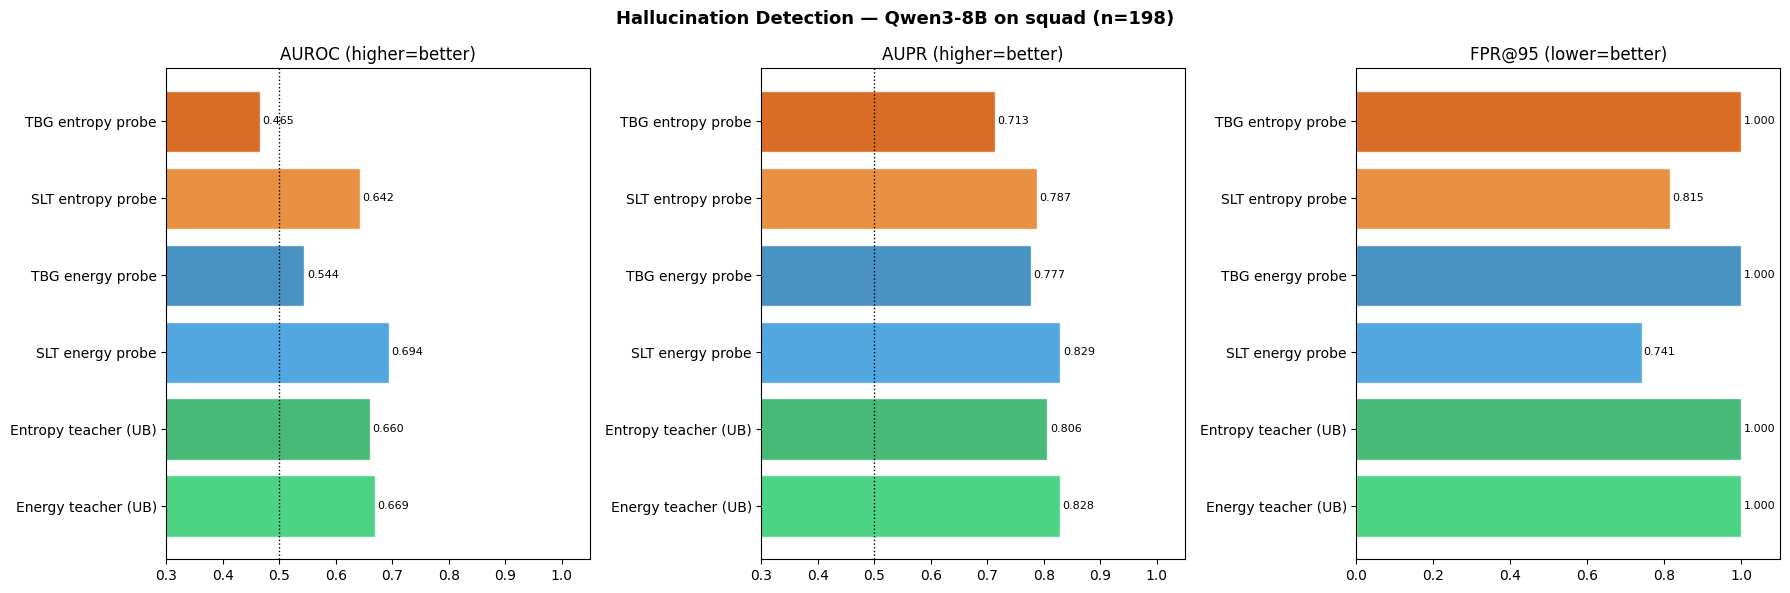

In [14]:
# ── Performance comparison bar chart ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
names  = [s[0] for s in sys_results]
colors = ['#2ecc71', '#27ae60', '#3498db', '#2980b9', '#e67e22', '#d35400']

for ax, metric, title in zip(axes, ['auroc', 'aupr', 'fpr95'],
                              ['AUROC (higher=better)', 'AUPR (higher=better)', 'FPR@95 (lower=better)']):
    vals = [s[1][metric]['mean'] for s in sys_results]
    bars = ax.barh(names, vals, color=colors, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=8)
    if metric == 'fpr95':
        ax.set_xlim(0, 1.1)
    else:
        ax.axvline(0.5, color='black', ls=':', lw=1)
        ax.set_xlim(0.3, 1.05)
    ax.set_title(title)

plt.suptitle(f'Hallucination Detection \u2014 {MODEL_LABEL} on {EVAL_DATASET} (n={D_eval.N})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig(f'performance_comparison_benchmark_{EVAL_SHORT}'); plt.show()

Saved: d:\Github Repositories\SemanticEnergy\notebooks\figures\roc_pr_curves_benchmark_squad_qwen3-8b.png


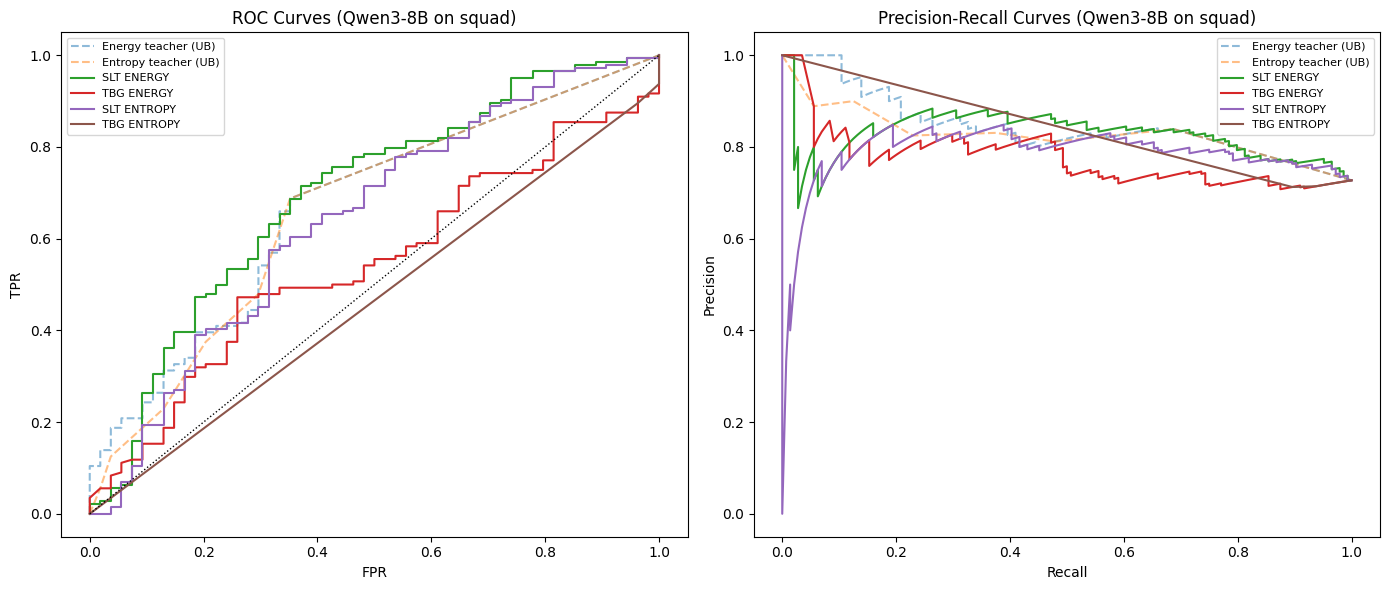

In [15]:
# ── ROC & Precision-Recall curves ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC curves
ax = axes[0]
for name, scores in systems[:2]:  # Teachers
    fpr, tpr, _ = roc_curve(y_hall, scores)
    ax.plot(fpr, tpr, ls='--', alpha=0.5, label=name)
for pname in ['slt_energy', 'tbg_energy', 'slt_entropy', 'tbg_entropy']:
    scores = get_hall_score(pname, trained_probes[pname], D_eval)
    fpr_vals, tpr_vals, _ = roc_curve(y_hall, scores)
    label = pname.replace('_', ' ').upper()
    ax.plot(fpr_vals, tpr_vals, label=label)
ax.plot([0,1], [0,1], 'k:', lw=1)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title(f'ROC Curves ({MODEL_LABEL} on {EVAL_DATASET})'); ax.legend(fontsize=8)

# PR curves
ax = axes[1]
for name, scores in systems[:2]:
    prec, rec, _ = precision_recall_curve(y_hall, scores)
    ax.plot(rec, prec, ls='--', alpha=0.5, label=name)
for pname in ['slt_energy', 'tbg_energy', 'slt_entropy', 'tbg_entropy']:
    scores = get_hall_score(pname, trained_probes[pname], D_eval)
    prec, rec, _ = precision_recall_curve(y_hall, scores)
    ax.plot(rec, prec, label=pname.replace('_', ' ').upper())
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title(f'Precision-Recall Curves ({MODEL_LABEL} on {EVAL_DATASET})'); ax.legend(fontsize=8)

plt.tight_layout()
save_fig(f'roc_pr_curves_benchmark_{EVAL_SHORT}'); plt.show()

Saved: d:\Github Repositories\SemanticEnergy\notebooks\figures\confusion_matrices_benchmark_squad_qwen3-8b.png


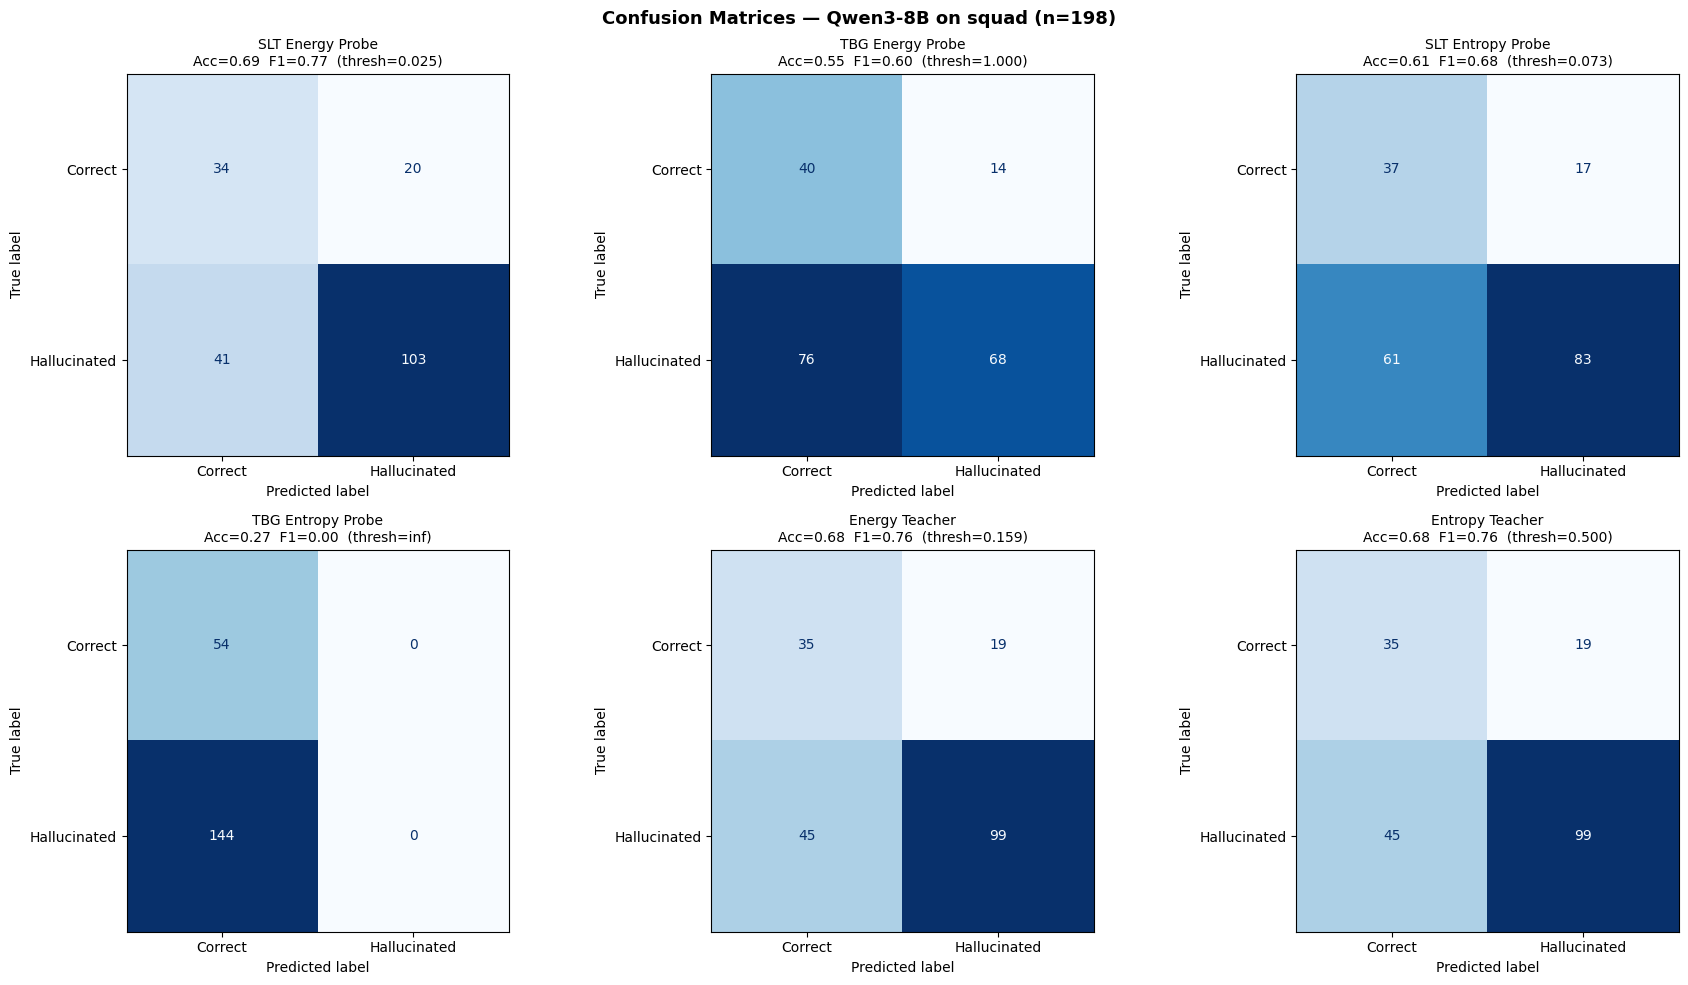


System                   TP   FP   TN   FN    Acc   Prec    Rec     F1
------------------------------------------------------------------------
SLT Energy Probe        103   20   34   41  0.692  0.837  0.715  0.772
TBG Energy Probe         68   14   40   76  0.545  0.829  0.472  0.602
SLT Entropy Probe        83   17   37   61  0.606  0.830  0.576  0.680
TBG Entropy Probe         0    0   54  144  0.273  0.000  0.000  0.000
Energy Teacher           99   19   35   45  0.677  0.839  0.688  0.756
Entropy Teacher          99   19   35   45  0.677  0.839  0.688  0.756


In [16]:
# ── Confusion matrices at optimal (Youden's J) threshold ─────────────────────
cm_systems = [
    ('SLT Energy Probe',  get_hall_score('slt_energy', trained_probes['slt_energy'], D_eval)),
    ('TBG Energy Probe',  get_hall_score('tbg_energy', trained_probes['tbg_energy'], D_eval)),
    ('SLT Entropy Probe', get_hall_score('slt_entropy', trained_probes['slt_entropy'], D_eval)),
    ('TBG Entropy Probe', get_hall_score('tbg_entropy', trained_probes['tbg_entropy'], D_eval)),
    ('Energy Teacher',    1 - D_eval.energy_score_raw),
    ('Entropy Teacher',   D_eval.entropy_score_raw),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

cm_summary = []
for ax, (name, scores) in zip(axes, cm_systems):
    thresh = optimal_threshold(y_hall.astype(int), scores)
    y_pred = (scores >= thresh).astype(int)
    cm = confusion_matrix(y_hall.astype(int), y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Correct', 'Hallucinated'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    tn, fp, fn, tp = cm.ravel()
    accuracy  = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    ax.set_title(f'{name}\nAcc={accuracy:.2f}  F1={f1:.2f}  (thresh={thresh:.3f})', fontsize=10)
    cm_summary.append({'System': name, 'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
                       'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1': f1})

plt.suptitle(f'Confusion Matrices \u2014 {MODEL_LABEL} on {EVAL_DATASET} (n={len(y_hall)})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig(f'confusion_matrices_benchmark_{EVAL_SHORT}'); plt.show()

print(f"\n{'System':<22} {'TP':>4} {'FP':>4} {'TN':>4} {'FN':>4} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6}")
print('-' * 72)
for r in cm_summary:
    print(f"{r['System']:<22} {r['TP']:>4} {r['FP']:>4} {r['TN']:>4} {r['FN']:>4} "
          f"{r['Accuracy']:>6.3f} {r['Precision']:>6.3f} {r['Recall']:>6.3f} {r['F1']:>6.3f}")

In [17]:
# ── Teacher fidelity (diagnostic only — not a performance metric) ────────────
configs = [
    ('slt_energy',  'energy', 'slt', probe_bundle['best_energy_slt_range']),
    ('tbg_energy',  'energy', 'tbg', probe_bundle['best_energy_tbg_range']),
    ('slt_entropy', 'entropy', 'slt', probe_bundle['best_entropy_slt_range']),
    ('tbg_entropy', 'entropy', 'tbg', probe_bundle['best_entropy_tbg_range']),
]

print(f"Teacher fidelity on {EVAL_DATASET} (Spearman rho — diagnostic only):")
print(f"{'Probe':<15} {'Teacher':<20} {'Spearman rho':>12} {'p-value':>12}")
print("-" * 62)
for pname, teacher, tok, lr in configs:
    teacher_key = f'{teacher}_score_raw'
    raw_teacher = getattr(D_eval, teacher_key)
    X = get_range_X(D_eval, lr, tok)
    p_info = trained_probes[pname]
    probe_score = p_info['probe'].predict_proba(p_info['scaler'].transform(clean_X(X)))[:, 1]
    rho, p = spearmanr(probe_score, raw_teacher)
    print(f"{pname:<15} {teacher_key:<20} {rho:>12.4f} {p:>12.2e}")

Teacher fidelity on squad (Spearman rho — diagnostic only):
Probe           Teacher              Spearman rho      p-value
--------------------------------------------------------------
slt_energy      energy_score_raw           0.2680     1.35e-04
tbg_energy      energy_score_raw           0.0761     2.87e-01
slt_entropy     entropy_score_raw          0.1974     5.31e-03
tbg_entropy     entropy_score_raw         -0.1151     1.06e-01


## 2.5 — Runtime Benchmark

Measure average wall-clock time per query for each inference mode:
- **Full Semantic Energy** — multi-sample generation + NLI clustering + energy calculation
- **Fast SLT** — 1 generation + 1 forward pass (probe on last-token-before-EOS hidden state)
- **Fast TBG** — 1 forward pass only (probe on last-token-before-generation hidden state)

In [ ]:
# ── Runtime benchmark ─────────────────────────────────────────────────────────
import time

RUNTIME_N = min(20, len(dataset_subset))  # number of questions to benchmark
runtime_questions = [dataset_subset[i]['question'] for i in range(RUNTIME_N)]

# ── Warm-up (1 query, discarded) ─────────────────────────────────────────────
_ = engine.score_with_tbg_probe(runtime_questions[0], probe_bundle)
torch.cuda.synchronize()

# ── 1. Full Semantic Energy (multi-sample generation + clustering + energy) ──
full_se_times = []
for q in tqdm(runtime_questions, desc="Full SE"):
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    gen_data = engine.generate_responses(q, num_samples=NUM_SAMPLES)
    clusters = engine.find_semantic_clusters(q, [d['answer'] for d in gen_data])
    probs_se, logits_se = cal_flow(
        [d['probs'] for d in gen_data],
        [d['logits'] for d in gen_data],
        clusters, fermi_mu=None)
    torch.cuda.synchronize()
    full_se_times.append(time.perf_counter() - t0)

# ── 2. Fast SLT (1 generation + 1 forward pass + probe) ─────────────────────
slt_times = []
for q in tqdm(runtime_questions, desc="Fast SLT"):
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    _ = engine.score_with_slt_probe(q, probe_bundle)
    torch.cuda.synchronize()
    slt_times.append(time.perf_counter() - t0)

# ── 3. Fast TBG (1 forward pass + probe, no generation) ─────────────────────
tbg_times = []
for q in tqdm(runtime_questions, desc="Fast TBG"):
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    _ = engine.score_with_tbg_probe(q, probe_bundle)
    torch.cuda.synchronize()
    tbg_times.append(time.perf_counter() - t0)

# ── Results ──────────────────────────────────────────────────────────────────
avg_full = np.mean(full_se_times)
avg_slt  = np.mean(slt_times)
avg_tbg  = np.mean(tbg_times)

print(f"\nRuntime Benchmark ({RUNTIME_N} queries, {MODEL_LABEL})")
print(f"{'─'*75}")
print(f"{'Method':<25} {'Avg (s)':>10} {'Std (s)':>10} {'Model calls':>30} {'Notes'}")
print(f"{'─'*75}")
print(f"{'Full Semantic Energy':<25} {avg_full:>10.2f} {np.std(full_se_times):>10.2f} {'Multi-sample':>30}   Expensive baseline")
print(f"{'Fast SLT':<25} {avg_slt:>10.2f} {np.std(slt_times):>10.2f} {'1 generation + 1 fwd pass':>30}   Probe approximation")
print(f"{'Fast TBG':<25} {avg_tbg:>10.2f} {np.std(tbg_times):>10.2f} {'1 forward pass':>30}   Fastest mode")
print(f"{'─'*75}")
print(f"\nSpeedup vs Full SE:  SLT = {avg_full/avg_slt:.1f}×,  TBG = {avg_full/avg_tbg:.1f}×")

## 3 — Cross-Dataset Comparison

Run this section **after** running the notebook for all 3 datasets.
It loads saved benchmark results and builds a comparison table.

In [18]:
# ── Load all available benchmark results ─────────────────────────────────────
import pandas as pd

benchmark_datasets = {
    'triviaqa': 'TriviaQA (held-out)',
    'nqopen':   'NQ-Open',
    'squad':    'SQuAD',
}

all_results = {}
for ds_short, ds_label in benchmark_datasets.items():
    path = os.path.join(DATA_DIR, f'benchmark_{MODEL_SHORT}_{ds_short}.pkl')
    if not os.path.exists(path):
        print(f"  [{ds_label}] Not found: {path}")
        continue
    with open(path, 'rb') as f:
        recs = pickle.load(f)
    # Filter valid
    recs = [r for r in recs if r['emb_tok_before_eos'] is not None
            and r['emb_last_tok_before_gen'] is not None]
    D = ProbeDataset(recs, name=ds_short)
    y = 1 - D.correctness
    ds_systems = [
        ('Energy teacher (UB)',  1 - D.energy_score_raw),
        ('Entropy teacher (UB)', D.entropy_score_raw),
        ('SLT energy probe',     get_hall_score('slt_energy', trained_probes['slt_energy'], D)),
        ('TBG energy probe',     get_hall_score('tbg_energy', trained_probes['tbg_energy'], D)),
        ('SLT entropy probe',    get_hall_score('slt_entropy', trained_probes['slt_entropy'], D)),
        ('TBG entropy probe',    get_hall_score('tbg_entropy', trained_probes['tbg_entropy'], D)),
    ]
    results = {}
    for name, scores in ds_systems:
        results[name] = full_eval(y, scores)
    results['_correctness_rate'] = float(D.correctness.mean())
    results['_n'] = D.N
    all_results[ds_label] = results
    print(f"  [{ds_label}] Loaded {D.N} records (correctness={D.correctness.mean():.1%})")

print(f"\nLoaded {len(all_results)} benchmark datasets.")

ProbeDataset 'triviaqa': N=947, layers=37, hidden=4096
  [TriviaQA (held-out)] Loaded 947 records (correctness=53.5%)
ProbeDataset 'nqopen': N=200, layers=37, hidden=4096
  [NQ-Open] Loaded 200 records (correctness=32.0%)
ProbeDataset 'squad': N=198, layers=37, hidden=4096
  [SQuAD] Loaded 198 records (correctness=27.3%)

Loaded 3 benchmark datasets.


In [19]:
# ── Cross-dataset summary table ──────────────────────────────────────────────
if len(all_results) == 0:
    print("No benchmark results found. Run the notebook for at least one dataset first.")
else:
    system_names = ['Energy teacher (UB)', 'Entropy teacher (UB)',
                    'SLT energy probe', 'TBG energy probe',
                    'SLT entropy probe', 'TBG entropy probe']

    for metric, metric_label in [('auroc', 'AUROC'), ('aupr', 'AUPR'), ('fpr95', 'FPR@95')]:
        rows = []
        for sname in system_names:
            row = {'System': sname}
            for ds_label, results in all_results.items():
                if sname in results:
                    row[ds_label] = f"{results[sname][metric]:.4f}"
                else:
                    row[ds_label] = '—'
            rows.append(row)
        # Add correctness rate row
        cr_row = {'System': 'Correctness rate'}
        for ds_label, results in all_results.items():
            cr_row[ds_label] = f"{results['_correctness_rate']:.1%}"
        rows.append(cr_row)
        n_row = {'System': 'N'}
        for ds_label, results in all_results.items():
            n_row[ds_label] = str(results['_n'])
        rows.append(n_row)

        df = pd.DataFrame(rows).set_index('System')
        print(f"\n{'='*60}")
        print(f"  {metric_label} — {MODEL_LABEL}")
        print(f"{'='*60}")
        print(df.to_string())
        print()


  AUROC — Qwen3-8B
                     TriviaQA (held-out) NQ-Open   SQuAD
System                                                  
Energy teacher (UB)               0.7680  0.6949  0.6687
Entropy teacher (UB)              0.7588  0.7075  0.6598
SLT energy probe                  0.7824  0.6361  0.6938
TBG energy probe                  0.7546  0.5082  0.5442
SLT entropy probe                 0.7618  0.6450  0.6422
TBG entropy probe                 0.7288  0.4970  0.4653
Correctness rate                   53.5%   32.0%   27.3%
N                                    947     200     198


  AUPR — Qwen3-8B
                     TriviaQA (held-out) NQ-Open   SQuAD
System                                                  
Energy teacher (UB)               0.7380  0.7997  0.8284
Entropy teacher (UB)              0.7035  0.8054  0.8056
SLT energy probe                  0.7431  0.7801  0.8287
TBG energy probe                  0.7020  0.6932  0.7769
SLT entropy probe                 0.7262  0.7804

Saved: d:\Github Repositories\SemanticEnergy\notebooks\figures\generalization_comparison_qwen3-8b_qwen3-8b.png


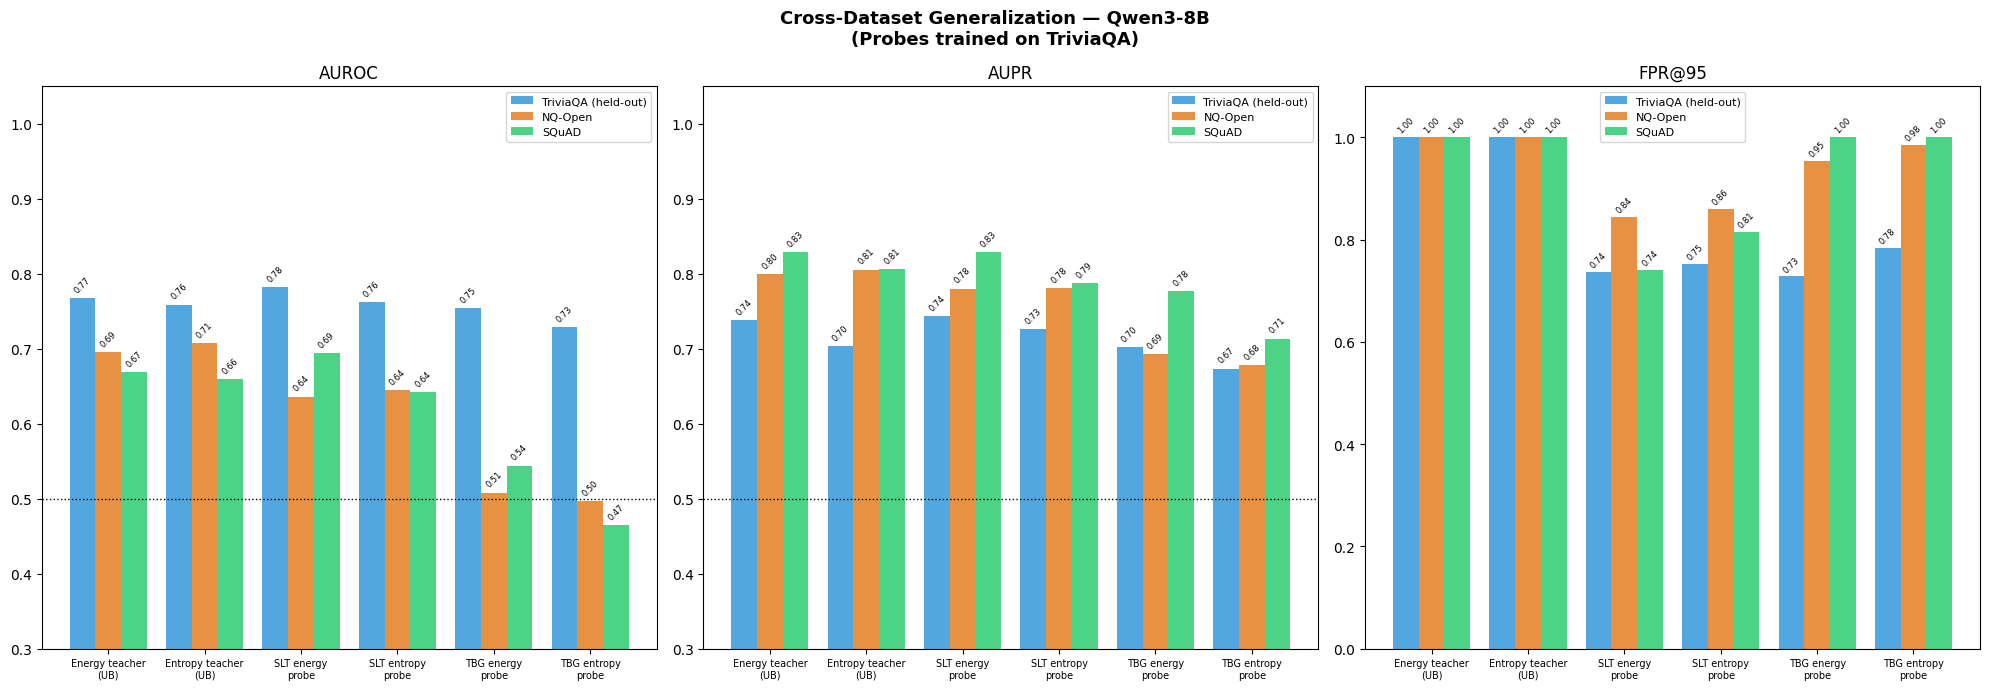

In [20]:
# ── Generalization comparison plot ────────────────────────────────────────────
if len(all_results) >= 2:
    system_names = ['Energy teacher (UB)', 'Entropy teacher (UB)',
                    'SLT energy probe', 'SLT entropy probe',
                    'TBG energy probe', 'TBG entropy probe']
    ds_labels = list(all_results.keys())
    ds_colors = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c'][:len(ds_labels)]

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    x = np.arange(len(system_names))
    width = 0.8 / len(ds_labels)

    for ax, metric, title in zip(axes, ['auroc', 'aupr', 'fpr95'],
                                  ['AUROC', 'AUPR', 'FPR@95']):
        for j, (ds_label, color) in enumerate(zip(ds_labels, ds_colors)):
            vals = [all_results[ds_label].get(sname, {}).get(metric, 0) for sname in system_names]
            offset = (j - len(ds_labels)/2 + 0.5) * width
            bars = ax.bar(x + offset, vals, width, label=ds_label, color=color, alpha=0.85)
            for bar, val in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                        f'{val:.2f}', ha='center', va='bottom', fontsize=6, rotation=45)
        ax.set_xticks(x)
        ax.set_xticklabels([s.replace(' (UB)', '\n(UB)').replace(' probe', '\nprobe')
                            for s in system_names], fontsize=7, rotation=0)
        ax.set_title(title)
        ax.legend(fontsize=8)
        if metric != 'fpr95':
            ax.axhline(0.5, color='black', ls=':', lw=1)
            ax.set_ylim(0.3, 1.05)
        else:
            ax.set_ylim(0, 1.1)

    plt.suptitle(f'Cross-Dataset Generalization \u2014 {MODEL_LABEL}\n(Probes trained on TriviaQA)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    save_fig(f'generalization_comparison_{MODEL_SHORT}')
    plt.show()
else:
    print("Need at least 2 benchmark datasets for comparison plot. Run the notebook for more datasets.")

In [21]:
# ── Save benchmark results for this run ──────────────────────────────────────
benchmark_result = {
    'model_id': MODEL_ID,
    'train_dataset': TRAIN_DATASET,
    'eval_dataset': EVAL_DATASET,
    'num_questions': D_eval.N,
    'correctness_rate': float(D_eval.correctness.mean()),
    'hallucination_rate': float(y_hall.mean()),
    'systems': {name: {'auroc': r['auroc']['mean'], 'aupr': r['aupr']['mean'],
                       'fpr95': r['fpr95']['mean'],
                       'auroc_ci': [r['auroc']['lo'], r['auroc']['hi']],
                       'aupr_ci': [r['aupr']['lo'], r['aupr']['hi']],
                       'fpr95_ci': [r['fpr95']['lo'], r['fpr95']['hi']]}
               for name, r in sys_results},
    'confusion_matrices': cm_summary,
}

out = os.path.join(DATA_DIR, f'benchmark_results_{MODEL_SHORT}_{EVAL_SHORT}.pkl')
with open(out, 'wb') as f: pickle.dump(benchmark_result, f)
print(f"Benchmark results saved: {out}")
print(f"\nDone! Run this notebook with the next EVAL_DATASET to build the cross-dataset comparison.")

Benchmark results saved: d:\Github Repositories\SemanticEnergy\backend\data\benchmark_results_qwen3-8b_squad.pkl

Done! Run this notebook with the next EVAL_DATASET to build the cross-dataset comparison.
